# Results Analysis

This notebook analyzes the exported JSON result files under `results/` and focuses on:

- pipeline order between `simulation/` and `detection/`
- PnL fields available in the exported results
- aggregate PnL by result group
- top PnL examples
- simple plots for comparison


## Pipeline Order

- `simulation/path_builder.py` comes before `simulation/simulate_paths.py`
- `detection/` is a separate live/on-chain detection pipeline
- `simulation` produces theoretical profitable path windows
- `detection` produces detected arbitrage transactions with realized PnL fields

In [1]:
from pathlib import Path
import json
from statistics import mean

import pandas as pd
import matplotlib.pyplot as plt

def is_project_root(candidate: Path) -> bool:
    return (
        (candidate / 'results').is_dir()
        and (candidate / 'simulation').is_dir()
        and (candidate / 'detection').is_dir()
    )

def detect_project_root(start: Path) -> Path:
    # Common notebook case: opened from the Analysis/ folder inside the repo.
    if start.name.lower() == 'analysis' and is_project_root(start.parent):
        return start.parent

    for candidate in [start] + list(start.parents):
        if is_project_root(candidate):
            return candidate

    raise FileNotFoundError(
        'Could not locate project root containing results/, simulation/, and detection/. '
        'Set ROOT manually if needed.'
    )

ROOT = detect_project_root(Path.cwd().resolve())
RESULTS_DIR = ROOT / 'results'
ANALYSIS_DIR = ROOT / 'Analysis'
ANALYSIS_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

ROOT, RESULTS_DIR

(WindowsPath('C:/Users/Fabian/Desktop/598project/DeFi-Cross-Rollup-Arbitrage'),
 WindowsPath('C:/Users/Fabian/Desktop/598project/DeFi-Cross-Rollup-Arbitrage/results'))

In [2]:
sections = {
    'simulation_cross_chain': sorted((RESULTS_DIR / 'simulation' / 'cross_chain_profitable_paths').glob('cross_chain_profitable_paths_*.json')),
    'simulation_single_chain': sorted((RESULTS_DIR / 'simulation' / 'single_chain_profitable_paths').glob('single_chain_profitable_paths_*.json')),
    'detection_arbitrum': sorted((RESULTS_DIR / 'detection' / 'arbitrum').glob('detected_single_chain_arbitrage_arbitrum_*.json')),
    'detection_base': sorted((RESULTS_DIR / 'detection' / 'base').glob('detected_single_chain_arbitrage_base_*.json')),
    'detection_optimism': sorted((RESULTS_DIR / 'detection' / 'optimism').glob('detected_single_chain_arbitrage_optimism_*.json')),
}

pd.DataFrame(
    [{'section': name, 'file_count': len(files), 'first_file': str(files[0].relative_to(ROOT)) if files else None} for name, files in sections.items()]
)

,section,file_count,first_file
0,simulation_cross_chain,5,results\simulation\cross_chain_profitable_path...
1,simulation_single_chain,13,results\simulation\single_chain_profitable_pat...
2,detection_arbitrum,1,results\detection\arbitrum\detected_single_cha...
3,detection_base,3,results\detection\base\detected_single_chain_a...
4,detection_optimism,1,results\detection\optimism\detected_single_cha...


In [3]:
def read_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


datasets = {}
for name, files in sections.items():
    rows = []
    for file in files:
        rows.extend(read_jsonl(file))
    datasets[name] = rows

pd.Series({name: len(rows) for name, rows in datasets.items()}, name='row_count')

simulation_cross_chain      43199
simulation_single_chain    122401
detection_arbitrum           5409
detection_base              22860
detection_optimism           7890
Name: row_count, dtype: int64

## Inspect The Head Of Each Result Type

This confirms the main PnL field exposed by the exported JSON files.

In [4]:
def head_columns(rows, n=1):
    if not rows:
        return pd.DataFrame()
    return pd.json_normalize(rows[:n])


for name in datasets:
    print(f'=== {name} ===')
    display(head_columns(datasets[name], 1).T.head(25))

=== simulation_cross_chain ===


,0
id,c3b9c17013e3807e2d6c8fdca6ea177fb4042d1517d742...
timestamp_range_start,1730419200
timestamp_range_stop,1730419202
number_of_updated_pools,5
number_of_updated_paths,17512
number_of_paths_with_positive_gains,420
number_of_simulated_paths,37
number_of_profitable_non_conflicting_paths,3
profitable_non_conflicting_paths,"[{'path': [{'chain': 'base', 'address': '0xd56..."
total_profit_usd,1.490639


=== simulation_single_chain ===


,0
id,3b086715035346acd9230c84c2c9906e3b92de51e239e9...
chain,base
block_number,21814927
timestamp_range_start,1730419200
timestamp_range_stop,1730419201
number_of_updated_pools,4
number_of_updated_paths,1434
number_of_paths_with_positive_gains,0
number_of_simulated_paths,0
number_of_profitable_non_conflicting_paths,0


=== detection_arbitrum ===


,0
id,8fc4d476f5547a293a3757378846064701dd146bd6289d...
block_number,269733580
block_timestamp,1730419220
miner,0xA4b000000000000000000073657175656e636572
arbitrages,"[{'swaps': [{'index': 24, 'in_token': '0xaf88d..."
eth_usd_price,2524.73
total_cost_eth,0.000003
total_cost_usd,0.007939
total_gain_eth,0.000005
total_gain_usd,0.011494


=== detection_base ===


,0
id,74afeec48216a35f89fa22e40c1386028d72bafc1a262b...
block_number,21820327
block_timestamp,1730430001
miner,0x4200000000000000000000000000000000000011
arbitrages,"[{'swaps': [{'index': 79, 'in_token': '0x42000..."
eth_usd_price,2515.02
total_cost_eth,0.000001
total_cost_usd,0.003192
total_gain_eth,0.000001
total_gain_usd,0.003053


=== detection_optimism ===


,0
id,6171b123e5c11b8b3d3e8a24f306a21ac326a7f84ea13d...
block_number,127415612
block_timestamp,1730430001
miner,0x4200000000000000000000000000000000000011
arbitrages,"[{'swaps': [{'index': 30, 'in_token': '0x42000..."
eth_usd_price,2514.95
total_cost_eth,0.0
total_cost_usd,0.000605
total_gain_eth,0.0
total_gain_usd,0.00088


In [5]:
def summarize_rows(name, rows):
    pnl_key = 'total_profit_usd'
    profits = [r.get(pnl_key) for r in rows if isinstance(r.get(pnl_key), (int, float))]
    positive = [x for x in profits if x > 0]
    zero = [x for x in profits if x == 0]
    negative = [x for x in profits if x < 0]

    return {
        'name': name,
        'rows': len(rows),
        'pnl_rows': len(profits),
        'positive_rows': len(positive),
        'zero_rows': len(zero),
        'negative_rows': len(negative),
        'sum_profit_usd': round(sum(profits), 6) if profits else 0,
        'avg_profit_usd': round(mean(profits), 6) if profits else 0,
        'max_profit_usd': round(max(profits), 6) if profits else 0,
        'min_profit_usd': round(min(profits), 6) if profits else 0,
        'avg_positive_profit_usd': round(mean(positive), 6) if positive else 0,
        'avg_negative_profit_usd': round(mean(negative), 6) if negative else 0,
    }


summary_df = pd.DataFrame([summarize_rows(name, rows) for name, rows in datasets.items()])
summary_df

,name,rows,pnl_rows,positive_rows,zero_rows,negative_rows,sum_profit_usd,avg_profit_usd,max_profit_usd,min_profit_usd,avg_positive_profit_usd,avg_negative_profit_usd
0,simulation_cross_chain,43199,43199,34886,8313,0,1.764433e+06,40.844306,507.145838,0.000000,50.577113,0.000000
1,simulation_single_chain,122401,122401,13716,108685,0,8.909836e+02,0.007279,116.804360,0.000000,0.064959,0.000000
2,detection_arbitrum,5409,5235,4176,0,1059,1.297306e+03,0.247814,290.115529,-2.882497,0.438870,-0.505587
3,detection_base,22860,21905,17090,0,4815,2.761034e+04,1.260458,9106.754090,-7.024464,1.617921,-0.008293
4,detection_optimism,7890,7846,7741,0,105,1.130771e+02,0.014412,7.770361,-0.156738,0.014681,-0.005419


## Main PnL Takeaways

- Cross-chain simulation has the largest theoretical total PnL.
- Single-chain simulation is much weaker and mostly zero-PnL windows.
- Detection datasets are more realistic because they include costs and can be negative.
- Base detection is the strongest realized dataset in the exported files.

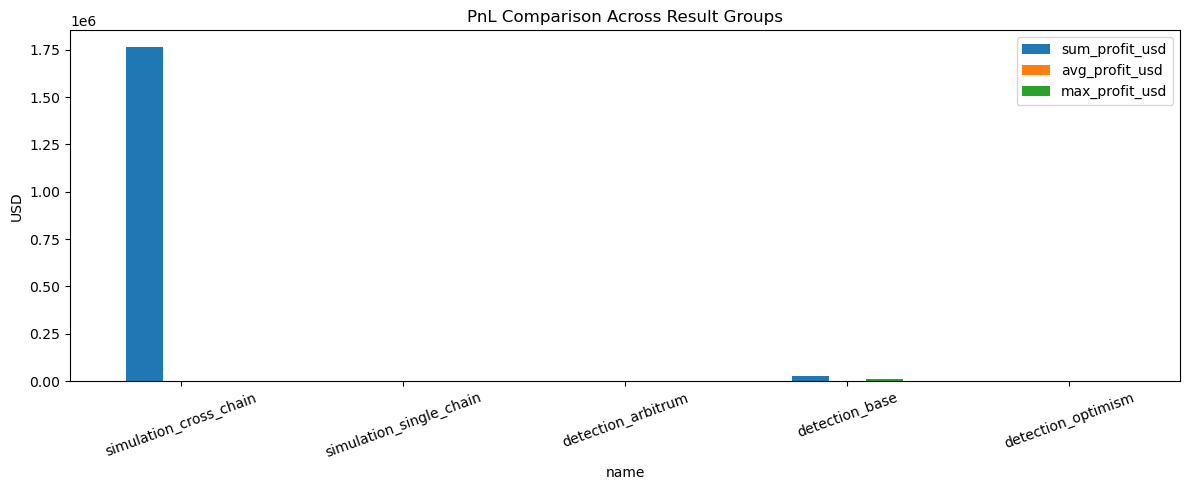

In [6]:
plot_df = summary_df.set_index('name')[['sum_profit_usd', 'avg_profit_usd', 'max_profit_usd']]
ax = plot_df.plot(kind='bar', figsize=(12, 5), rot=20, title='PnL Comparison Across Result Groups')
ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

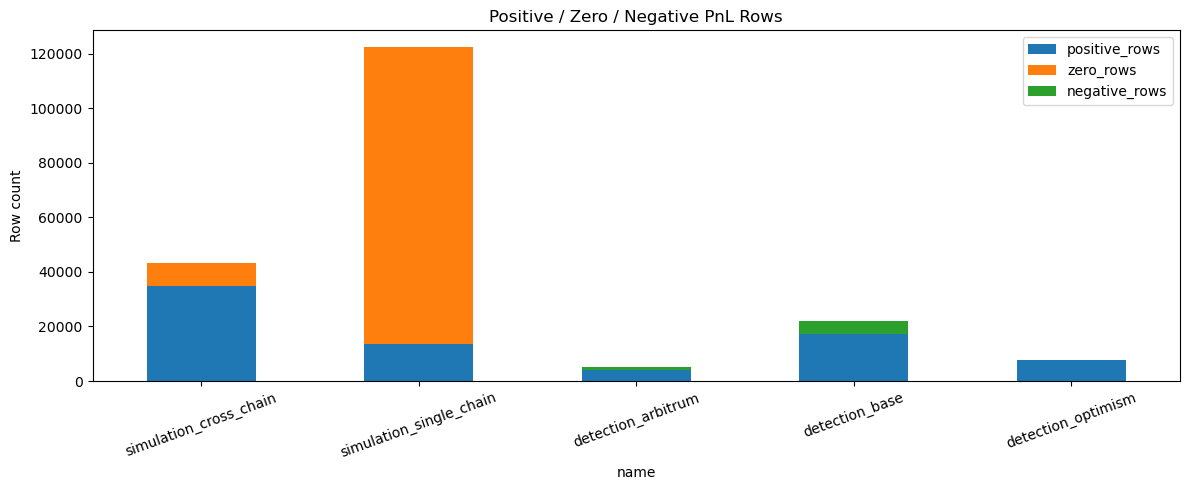

In [7]:
count_df = summary_df.set_index('name')[['positive_rows', 'zero_rows', 'negative_rows']]
ax = count_df.plot(kind='bar', stacked=True, figsize=(12, 5), rot=20, title='Positive / Zero / Negative PnL Rows')
ax.set_ylabel('Row count')
plt.tight_layout()
plt.show()

In [8]:
def top_examples(rows, limit=10):
    scored = [r for r in rows if isinstance(r.get('total_profit_usd'), (int, float))]
    scored.sort(key=lambda r: r['total_profit_usd'], reverse=True)
    top = []
    for r in scored[:limit]:
        item = {
            'profit_usd': r.get('total_profit_usd'),
            'timestamp_range_start': r.get('timestamp_range_start'),
            'timestamp_range_stop': r.get('timestamp_range_stop'),
            'block_number': r.get('block_number'),
            'chain': r.get('chain'),
            'id': r.get('id'),
        }
        if 'number_of_profitable_non_conflicting_paths' in r:
            item['number_of_profitable_non_conflicting_paths'] = r.get('number_of_profitable_non_conflicting_paths')
        tx = r.get('transaction')
        if isinstance(tx, dict):
            item['tx_hash'] = tx.get('hash')
        top.append(item)
    return pd.DataFrame(top)


top_tables = {name: top_examples(rows, 10) for name, rows in datasets.items()}
top_tables['simulation_cross_chain']

,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,number_of_profitable_non_conflicting_paths
0,507.145838,1730481168,1730481170,None,None,0420dffb1b7b91e0a4c97fe9017c92f8b35c3795d96208...,1
1,506.848189,1730484830,1730484832,None,None,769953fa351d9fe00d6c7d8a22bd1c5a4bbe54fd7cccc0...,2
2,506.710752,1730484800,1730484802,None,None,edba7218e8f8b8f69a14fc76fad01a2ae63fc54152a381...,2
3,506.424309,1730484898,1730484900,None,None,72b51ef5a729bdf5815683b37d43826f81411876c70f17...,1
4,506.422887,1730484918,1730484920,None,None,778bb305fb7f4655cc130766630cd9d4be88d8543d9c12...,1
5,506.409071,1730484938,1730484940,None,None,d6c80748155dbd86739f7e298139a559f89240313daa4d...,2
6,506.376975,1730484870,1730484872,None,None,e3ba97864f6c48926f1eb0fa819434c0002a379cd1a69c...,2
7,506.331690,1730484770,1730484772,None,None,3104174eb3840a7efed303b673c27a9e3794a9cbd8b1c6...,2
8,506.313461,1730484712,1730484714,None,None,e67661e83cfa155bf90a5047591fb1b960fa85fbcb4945...,2
9,506.284463,1730484948,1730484950,None,None,de211d630c720c0032441f4d10aa6339f283e6df576829...,2


In [9]:
for name, table in top_tables.items():
    print(f'=== Top PnL: {name} ===')
    display(table)

=== Top PnL: simulation_cross_chain ===


,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,number_of_profitable_non_conflicting_paths
0,507.145838,1730481168,1730481170,None,None,0420dffb1b7b91e0a4c97fe9017c92f8b35c3795d96208...,1
1,506.848189,1730484830,1730484832,None,None,769953fa351d9fe00d6c7d8a22bd1c5a4bbe54fd7cccc0...,2
2,506.710752,1730484800,1730484802,None,None,edba7218e8f8b8f69a14fc76fad01a2ae63fc54152a381...,2
3,506.424309,1730484898,1730484900,None,None,72b51ef5a729bdf5815683b37d43826f81411876c70f17...,1
4,506.422887,1730484918,1730484920,None,None,778bb305fb7f4655cc130766630cd9d4be88d8543d9c12...,1
5,506.409071,1730484938,1730484940,None,None,d6c80748155dbd86739f7e298139a559f89240313daa4d...,2
6,506.376975,1730484870,1730484872,None,None,e3ba97864f6c48926f1eb0fa819434c0002a379cd1a69c...,2
7,506.331690,1730484770,1730484772,None,None,3104174eb3840a7efed303b673c27a9e3794a9cbd8b1c6...,2
8,506.313461,1730484712,1730484714,None,None,e67661e83cfa155bf90a5047591fb1b960fa85fbcb4945...,2
9,506.284463,1730484948,1730484950,None,None,de211d630c720c0032441f4d10aa6339f283e6df576829...,2


=== Top PnL: simulation_single_chain ===


,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,number_of_profitable_non_conflicting_paths
0,116.804360,1730483642,1730483643,269990092,arbitrum,1c669a69a82dadc056a2f2fd7c28493379103ef39059b2...,1
1,67.674229,1730424689,1730424690,269755408,arbitrum,4ba1bba96e40c44cdeefb325e1aec7c4c58ab3462d8bdc...,1
2,30.577505,1730471809,1730471810,269943092,arbitrum,85b9140ef7159a858ba1fbc3bd3924fbe369396250890f...,1
3,17.648821,1730477411,1730477412,269965346,arbitrum,70f69d19f82b0a6fe2574975a3ad6fd742d560024c0800...,1
4,16.269339,1730470381,1730470382,269937399,arbitrum,32a4b2f2d85c219fd3f9d6207d2878374e79063004de9d...,1
5,14.911726,1730470400,1730470401,269937475,arbitrum,bd4bd746b7acee8c81cc5cb5fe56dc1e8554d416b38443...,1
6,14.598144,1730470382,1730470383,269937400,arbitrum,0522ee0ea58de06a100308eacd841e9cda43e3bafd012c...,2
7,14.027133,1730471839,1730471840,269943208,arbitrum,f9dd4a39b801089299fc2a17db57dd961e8807d0cbf0e0...,1
8,13.811509,1730431044,1730431045,269780618,arbitrum,e18998ca3f8d2b57cc5f8560eb387d9a1a864ab81b4264...,1
9,10.276143,1730476474,1730476475,269961608,arbitrum,c1022e422d768e84ada6a89c3ff7965930df9bb77a79dc...,3


=== Top PnL: detection_arbitrum ===


,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,tx_hash
0,290.115529,None,None,269778683,None,cc11748ce410905e241b07ebd332d60bd127ba008041ab...,95acb4209325a63a165376e1536726785051a7904bff24...
1,150.949014,None,None,269780619,None,abb0626d15e9915a121bf386787981caa9f4a5ba9410e8...,7d3348c894ae188ad25fd511e6b677d9338101325e2e34...
2,117.227050,None,None,269990093,None,5407dc5c60553e0b3ad6449ef817dc76f5bda1fc5ebc22...,c97dddae248bdc57fb70c493ed9994794fbe26728e6ec7...
3,79.116830,None,None,270026591,None,5905335cf1285e14194ad1ad4bd31a5b56c6f3311d9317...,eb0068fe731242f48e529aa6607cd70cd782397a1f19d0...
4,41.908512,None,None,269982245,None,b552b5be4cadbe6803bcb76e468a325e5abf97809f08ae...,4586503f21014cfa50b44ebec761c16a4953eb6beb3263...
5,38.862820,None,None,269879113,None,b5939dad2acb01dc0d1c23796557ad3db67a7b2e4cf4f7...,edfbf883c4c4e0f371e72067c51dad62d533a0ed46adc2...
6,34.914295,None,None,270062655,None,214b60bce3b10528dfb6c051d3acac8584c54a11853fc1...,1335e76cf7378f600eba8167183f927417bd72c6266617...
7,34.194636,None,None,269852439,None,220545a360f8bafb16c35b519792374805eefd1718df11...,a94523ab390d387a1f454dd112dee7806259e7867209eb...
8,31.620616,None,None,269963917,None,53197c727f4ef1f450f39745e0b722275e9f3e7664c464...,dc0c1312e53090ca250df3bfef73db9de298475da7f880...
9,30.340688,None,None,269771645,None,efa43fec4861cb0750b8eaeb76bc88122e215017becc25...,7a05766a65776bce16c153df59dfabbe1f9ff4d7762d6b...


=== Top PnL: detection_base ===


,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,tx_hash
0,9106.754090,None,None,21822773,None,95c83dc794291b0e4c0b425fff40767658e6ce23d0dbc0...,badacb26b49adf8a92716de7ce063508054cb4ab245b2f...
1,3385.064029,None,None,21822773,None,8b2963ca0024d154886ef1d54285da1684200106eeb02c...,ed36b760b9585052a9faa9193edfea45bbe6f2896f2f5d...
2,1103.036726,None,None,21855290,None,43746d0688b789da88107e051f776607e7ed9d91e635da...,6bfc3c16805340025ae167821a5ae47e076036c9eb148f...
3,1091.741345,None,None,21818807,None,2c8e678786f8a37fa64d388c8ab699cadd0bdf2f8dd50b...,13bf1a0e9cd459db57ab6e0dcd738b78db05aaa651bee9...
4,996.061766,None,None,21822530,None,fb1c9fffe9d1fd444919be50a297ae09f4857803808e51...,486d5a577624b99ea1c64562668a89f70fc3e2ba207358...
5,973.930011,None,None,21832296,None,e9f9380d6891a48f0897e818b39888f26185936ade313c...,99402007f8c49c92e4ffec9fbae4551a01dc8e0fd66de9...
6,536.097506,None,None,21815611,None,400049c79ee749582e8d0110cb7c8560a1c2b0f6a3f2e4...,de796ce73a4c327f68e332a7ba58792034c861a9d24dad...
7,478.560563,None,None,21830399,None,a3c6413fe4940e5751d3540f7aa3d216bf8c7d610cdff3...,0217dfbba8adcca52bf840941c13219953b64412033391...
8,477.420522,None,None,21845859,None,e92ad1255dfd9fe43dfacc7851a8974e34fabbeb78e4bb...,b391a6d0724d81213bc960fff492aacafc6855448e26be...
9,359.924459,None,None,21848847,None,9c095dfd168f8ef1b650a2a88dc3dda43293be555cd218...,b4b70d2742a2a3babc3b7089172f83dcad0f701dba14cf...


=== Top PnL: detection_optimism ===


,profit_usd,timestamp_range_start,timestamp_range_stop,block_number,chain,id,tx_hash
0,7.770361,None,None,127425299,None,293c25f3064240673ae53b06de8846c1ad735d6e91c67d...,b105aa9875857680abd61b83aa28132526e91f5b1a90b5...
1,4.462863,None,None,127446038,None,8ffacd5d3a5bada8f71c24dc662a1f0e5a204567b11116...,b542c39abaa823f216c97acf3072d54e7eee172a347425...
2,3.917421,None,None,127438242,None,c233dd7533d7f1d6aab7c091b42358a0ad06e69763c2b8...,5493ad37bcd57756aedc38428254424815679a3fdaca8c...
3,3.652768,None,None,127438227,None,e375d3c1c809dabdbf3bb72bcb3ade1f40e0e3e1da1635...,7ff28dd4fb343184e66604f55c660ccf7087d038d959a2...
4,3.546213,None,None,127438416,None,982bf63b5bc2e23dabee81cdec3bb09fb2d7ad36099597...,8a039322395fc825ba30e6e49a345b580445031e6c5583...
5,3.264788,None,None,127438241,None,cf57df0e7cd439bfda1643f879c3b09798435a618b6002...,3b00b1c95bd7c861203204a805e60a8471ae0cd85742a2...
6,2.758839,None,None,127438240,None,cc2cabaf61f7f74f731a0a278b2108d508dad032bc75f0...,030d510e4f27e34ca292bcb41165ac94960c8d22fbd462...
7,2.645422,None,None,127438241,None,8f65f749ce782478408df191778e128d44816313fad3b9...,facf6d915c2ae48ae56a3e6e26aee60d95b5ea9916499a...
8,1.994182,None,None,127433573,None,fc489e73937b05d67502b25f0b02b0002b26f930c58559...,b0737691239a7ac95cd8a281e35b6ab4944370b6e5efb1...
9,1.857114,None,None,127413604,None,114a70cd05be42d5db684e2c129d78b13055cba8e82699...,a06240eafe2240768d743230504cff6e443589a0eaea46...


## Interpretation

### Simulation vs Detection

- `simulation_cross_chain` looks like an upper-bound theoretical opportunity set.
- `simulation_single_chain` is much weaker and often zero.
- `detection_*` is better for realistic PnL because it includes transaction cost and can go negative.

### Best Realized Dataset

- `detection_base` has the strongest total and average realized PnL in the exported files.

### Caution On Cross-Chain PnL

The cross-chain simulated profits are likely overstated as executable profit because the current exported results do not model:

- bridge latency
- bridge fees
- inventory risk during cross-rollup movement
- failed execution and sequencing risk


In [10]:
summary_path = ANALYSIS_DIR / 'results_summary_from_notebook.csv'
summary_df.to_csv(summary_path, index=False)

for name, table in top_tables.items():
    table.to_csv(ANALYSIS_DIR / f'{name}_top_pnl.csv', index=False)

summary_path

WindowsPath('C:/Users/Fabian/Desktop/598project/DeFi-Cross-Rollup-Arbitrage/Analysis/results_summary_from_notebook.csv')